# 🚢 Titanic ML Avancé: Stacking + Ensemble + AutoML
## Features Intelligentes + Multiple Modèles + Optimisation Hyperparamètres

In [6]:
# ===== IMPORTER LES LIBRAIRIES NÉCESSAIRES =====
# Pandas et Numpy: manipulation de données
# Matplotlib et Seaborn: visualisations
# Sklearn: machine learning (modèles, métrics, preprocessing)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, 
    VotingClassifier, StackingClassifier, AdaBoostClassifier
)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, roc_curve, auc
)
import warnings
warnings.filterwarnings('ignore')

# ===== CHARGER LES DONNÉES =====
# Chargement du dataset Titanic (train et test)
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print("\n" + "="*70)
print("🚀 ADVANCED TITANIC SURVIVAL MODEL")
print("="*70)
print(f"Train: {train_df.shape} | Test: {test_df.shape}")


🚀 ADVANCED TITANIC SURVIVAL MODEL
Train: (891, 12) | Test: (418, 11)


## 🔧 Step 1: Feature Engineering Avancé

In [7]:
def advanced_feature_engineering(df, is_test=False):
    """
    Créer des features sophistiquées à partir des données brutes
    Objectif: Extraire plus d'information pour améliorer les prédictions
    """
    df = df.copy()
    
    # ===== FEATURES TEXTUELLES =====
    # Extraire le titre (Mr, Mrs, Miss, Master) du nom
    # Hypothèse: le titre peut indiquer le statut social et l'âge
    df['Title'] = df['Name'].str.extract('([A-Za-z]+)\\.', expand=False)
    title_map = {'Mr': 0, 'Mrs': 1, 'Miss': 2, 'Master': 3}
    df['Title'] = df['Title'].map(title_map).fillna(4)
    
    # Longueur du nom - pourrait indiquer le statut social
    df['NameLength'] = df['Name'].str.len()
    # Booléen: a-t-il un titre?
    df['HasTitle'] = df['Name'].str.contains('Mrs|Mr|Miss|Master').astype(int)
    
    # ===== FEATURES FAMILIALES =====
    # Taille familiale totale = frères/sœurs + parents + passager lui-même
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    # Voyage seul = plus de risque? (pas d'aide à bord)
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    # Famille nombreuse = plus de risque? (difficile à coordonner)
    df['IsLargeFamily'] = (df['FamilySize'] > 3).astype(int)
    # Avoir des enfants: les femmes avec enfants étaient prioritaires
    df['HasChildren'] = (df['Parch'] > 0).astype(int)
    # Log de la taille familiale: capture la non-linéarité
    df['FamilySizeLog'] = np.log1p(df['FamilySize'])
    
    # ===== FEATURES D'ÂGE =====
    # Sauvegarder l'âge original avant remplissage
    df['Age_original'] = df['Age'].copy()
    # Remplir les âges manquants par la médiane du titre (Mr, Mrs, etc.)
    # Logique: personnes avec même titre ont probablement âge similaire
    df['Age'] = df['Age'].fillna(df.groupby('Title')['Age'].transform('median'))
    # Remplir les manquants restants par la médiane générale
    df['Age'] = df['Age'].fillna(df['Age'].median())
    
    # Groupes d'âge - enfants avaient plus de priorité
    df['IsChild'] = (df['Age'] < 13).astype(int)
    # Adultes actifs
    df['IsAdult'] = ((df['Age'] >= 18) & (df['Age'] < 65)).astype(int)
    # Personnes âgées - peut indiquer fragilité
    df['IsSenior'] = (df['Age'] >= 65).astype(int)
    # Features polynomiales: capture la relation non-linéaire
    df['Age_squared'] = df['Age'] ** 2
    df['Age_log'] = np.log1p(df['Age'])
    
    # ===== FEATURES TARIFAIRES =====
    # Remplir les tarifs manquants par la médiane de la classe
    # Logique: classe détermine largement le prix
    df['Fare'] = df['Fare'].fillna(df.groupby('Pclass')['Fare'].transform('median'))
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    
    # Tarif par personne: si famille, le coût par personne diminue
    df['Fare_per_person'] = df['Fare'] / (df['FamilySize'] + 1)
    # Log et squared: capture non-linéarités du tarif
    df['Fare_log'] = np.log1p(df['Fare'])
    df['Fare_squared'] = df['Fare'] ** 2
    
    # ===== FEATURES CABINE =====
    # Avoir une cabine enregistrée = plus de privilèges/information
    df['HasCabin'] = (~df['Cabin'].isnull()).astype(int)
    # Lettre de la cabine: peut indiquer la zone du navire
    df['CabinLetter'] = df['Cabin'].str[0].map(lambda x: ord(x) if pd.notna(x) else 0)
    # Numéro de cabine: proximité d'accès aux canots?
    df['CabinNumber'] = df['Cabin'].str.extract('(\\d+)', expand=False).fillna(0).astype(int)
    
    # ===== FEATURES EMBARQUEMENT =====
    # Port d'embarquement: S=Southampton, C=Cherbourg, Q=Queenstown
    # Peut indiquer la classe socio-économique du passager
    df['Embarked'] = df['Embarked'].fillna('S')
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    
    # ===== FEATURES SEXE =====
    # Codage: 0=male, 1=female (critère majeur de survie)
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    
    # ===== FEATURES CLASSE =====
    # Créer des variables dummy pour chaque classe (One-Hot)
    df['IsFirstClass'] = (df['Pclass'] == 1).astype(int)
    df['IsSecondClass'] = (df['Pclass'] == 2).astype(int)
    df['IsThirdClass'] = (df['Pclass'] == 3).astype(int)
    
    # ===== FEATURES INTERACTIVES PUISSANTES =====
    # "Women and children first": femme ET première classe = très haut survie
    df['Female_X_FirstClass'] = df['Sex'] * df['IsFirstClass']
    # Femme ET enfant = très très haute priorité
    df['Female_X_Child'] = df['Sex'] * df['IsChild']
    # Adulte avec billet cher = plus éduqué, peut mieux agir
    df['Adult_X_Expensive'] = df['IsAdult'] * (df['Fare'] > df['Fare'].median()).astype(int)
    # Voyage seul en première classe = riche = plus de ressources
    df['Alone_X_FirstClass'] = df['IsAlone'] * df['IsFirstClass']
    # Enfant avec billet très cher = famille très riche
    df['Young_X_Expensive'] = df['IsChild'] * (df['Fare'] > df['Fare'].quantile(0.75)).astype(int)
    
    # ===== FEATURES STATISTIQUES =====
    # Ratio frères/sœurs par rapport aux parents
    df['SibSp_Parch_Ratio'] = (df['SibSp'] + 1) / (df['Parch'] + 1)
    # Nombre total de parents et frères/sœurs
    df['Total_relatives'] = df['SibSp'] + df['Parch']
    
    # ===== SÉLECTIONNER LES FEATURES FINALES =====
    # Garder toutes les features créées
    feature_cols = [
        'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
        'Title', 'FamilySize', 'IsAlone', 'IsLargeFamily', 'HasChildren',
        'IsChild', 'IsAdult', 'IsSenior', 'Age_squared', 'Age_log',
        'Fare_per_person', 'Fare_log', 'Fare_squared',
        'HasCabin', 'CabinLetter', 'CabinNumber',
        'IsFirstClass', 'IsSecondClass', 'IsThirdClass',
        'Female_X_FirstClass', 'Female_X_Child', 'Adult_X_Expensive',
        'Alone_X_FirstClass', 'Young_X_Expensive',
        'SibSp_Parch_Ratio', 'Total_relatives', 'NameLength'
    ]
    
    # Remplir tout NaN restant par la médiane (valeur sûre)
    for col in feature_cols:
        df[col] = df[col].fillna(df[col].median())
    
    return df[feature_cols], df

# ===== APPLIQUER L'INGÉNIERIE DE FEATURES =====
X_train, train_processed = advanced_feature_engineering(train_df)
X_test, test_processed = advanced_feature_engineering(test_df, is_test=True)
# Récupérer la variable cible (Survived)
y_train = train_df['Survived']

print(f"\n✓ Created {X_train.shape[1]} advanced features")
print(f"X_train shape: {X_train.shape}")
print(f"\nFeatures: {list(X_train.columns)[:10]}...")


✓ Created 34 advanced features
X_train shape: (891, 34)

Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone']...


## 🤖 Step 2: Stacking Ensemble Model

In [ ]:
# ===== SPLIT TRAIN/VALIDATION =====
# Diviser en train (80%) et validation (20%) de manière stratifiée
# Stratifié = garder le même ratio Survived dans train et val
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# ===== NORMALISER LES FEATURES =====
# StandardScaler: met chaque feature à moyenne=0, std=1
# Important pour: SVM, KNN, Logistic Regression
# Random Forest et Gradient Boosting ne nécessitent pas la normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_split)  # Fit sur train seulement
X_val_scaled = scaler.transform(X_val)                 # Appliquer sur val
X_test_scaled = scaler.transform(X_test)               # Appliquer sur test

print("\n" + "="*70)
print("🏗️ BUILDING STACKING ENSEMBLE")
print("="*70)

# ===== BASE LEARNERS (Niveau 0) =====
# Utiliser plusieurs modèles différents pour capturer différents patterns
# Chacun a ses forces:
# - Random Forest: capture interactions complexes, robuste aux outliers
# - Gradient Boosting: amélioration progressive, très accurate
# - SVM: trouve des limites complexes (non-linéaires)
# - KNN: basé sur voisins, bon pour patterns locaux
# - Logistic Regression: simple, rapide, bon baseline
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=15, 
                                   min_samples_split=5, random_state=42, n_jobs=-1)),
    ('gb', GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                       max_depth=5, random_state=42)),
    ('svc', SVC(kernel='rbf', probability=True, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
]

# ===== META LEARNER (Niveau 1) =====
# Après que les modèles de base fassent leurs prédictions,
# un modèle final apprend à combiner optimalement leurs résultats
# LogisticRegression: classificateur linéaire optimal pour combiner
meta_learner = LogisticRegression(max_iter=1000, random_state=42)

# ===== CRÉER LE STACKING CLASSIFIER =====
# Stacking = ensemble method à 2 niveaux
# Niveau 0: plusieurs modèles font leurs prédictions
# Niveau 1: méta-modèle apprend à combiner optimalement ces prédictions
# cv=5: utilise validation croisée 5-fold pour éviter overfitting
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    n_jobs=-1
)

print("\nBase Learners:")
for name, _ in base_learners:
    print(f"  ✓ {name.upper()}")
print(f"\nMeta-Learner: Logistic Regression")


🏗️ BUILDING STACKING ENSEMBLE

Base Learners:
  ✓ RF
  ✓ GB
  ✓ SVC
  ✓ KNN
  ✓ LR

Meta-Learner: Ridge Regression


## 📊 Step 3: Model Training & Evaluation

In [12]:
print("\n" + "="*70)
print("🎯 TRAINING MODELS")
print("="*70)

# ===== RÉINITIALISER LE STACKING ENSEMBLE =====
# S'assurer que le final_estimator est bien LogisticRegression
stacking_clf = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=200, max_depth=15, 
                                       min_samples_split=5, random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                           max_depth=5, random_state=42)),
        ('svc', SVC(kernel='rbf', probability=True, random_state=42)),
        ('knn', KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),
        ('lr', LogisticRegression(max_iter=1000, random_state=42))
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    n_jobs=-1
)

# ===== ENTRAÎNER ET COMPARER PLUSIEURS MODÈLES =====
# Entrainer 3 modèles: Random Forest, Gradient Boosting, et Stacking
# L'objectif: voir quel modèle fonctionne le mieux
models_to_compare = {
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=15, 
                                             min_samples_split=5, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                     max_depth=5, random_state=42),
    'Stacking Ensemble': stacking_clf
}

results = {}
predictions_dict = {}

for model_name, model in models_to_compare.items():
    print(f"\n▶️  Training {model_name}...")
    
    # ===== DONNÉES À UTILISER =====
    # Stacking: utiliser données normalisées (SVM et KNN à l'intérieur)
    # Tree-based: pas besoin de normalisation
    if model_name == 'Stacking Ensemble':
        model.fit(X_train_scaled, y_train_split)
        y_pred = model.predict(X_val_scaled)
        y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]  # Probabilités classe 1
    else:
        model.fit(X_train_split, y_train_split)
        y_pred = model.predict(X_val)
        y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    # ===== CALCULER LES MÉTRIQUES =====
    # Accuracy: % correct global
    acc = accuracy_score(y_val, y_pred)
    # Precision: de ce qu'on prédit positif, combien était vraiment positif
    prec = precision_score(y_val, y_pred)
    # Recall: de tous les positifs, combien on a trouvés
    rec = recall_score(y_val, y_pred)
    # F1-Score: moyenne harmonique de Precision et Recall
    f1 = f1_score(y_val, y_pred)
    # ROC-AUC: mesure la performance à tous les seuils
    auc_score = roc_auc_score(y_val, y_pred_proba)
    
    results[model_name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc_score
    }
    
    predictions_dict[model_name] = (y_pred, y_pred_proba)
    
    print(f"  ✓ Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC-AUC: {auc_score:.4f}")

# ===== TABLEAU COMPARATIF =====
# Afficher les résultats de tous les modèles côte à côte
print("\n" + "="*70)
print("📈 MODEL COMPARISON")
print("="*70)
results_df = pd.DataFrame(results).T
print(results_df.to_string())


🎯 TRAINING MODELS

▶️  Training Random Forest...
  ✓ Accuracy: 0.7933 | F1: 0.7132 | ROC-AUC: 0.8470

▶️  Training Gradient Boosting...
  ✓ Accuracy: 0.7989 | F1: 0.7231 | ROC-AUC: 0.8386

▶️  Training Stacking Ensemble...
  ✓ Accuracy: 0.8156 | F1: 0.7481 | ROC-AUC: 0.8602

📈 MODEL COMPARISON
                   Accuracy  Precision    Recall  F1-Score   ROC-AUC
Random Forest      0.793296   0.766667  0.666667  0.713178  0.847036
Gradient Boosting  0.798883   0.770492  0.681159  0.723077  0.838603
Stacking Ensemble  0.815642   0.790323  0.710145  0.748092  0.860211


## 🎨 Step 4: Visualizations


✓ Visualizations saved as 'advanced_model_analysis.png'


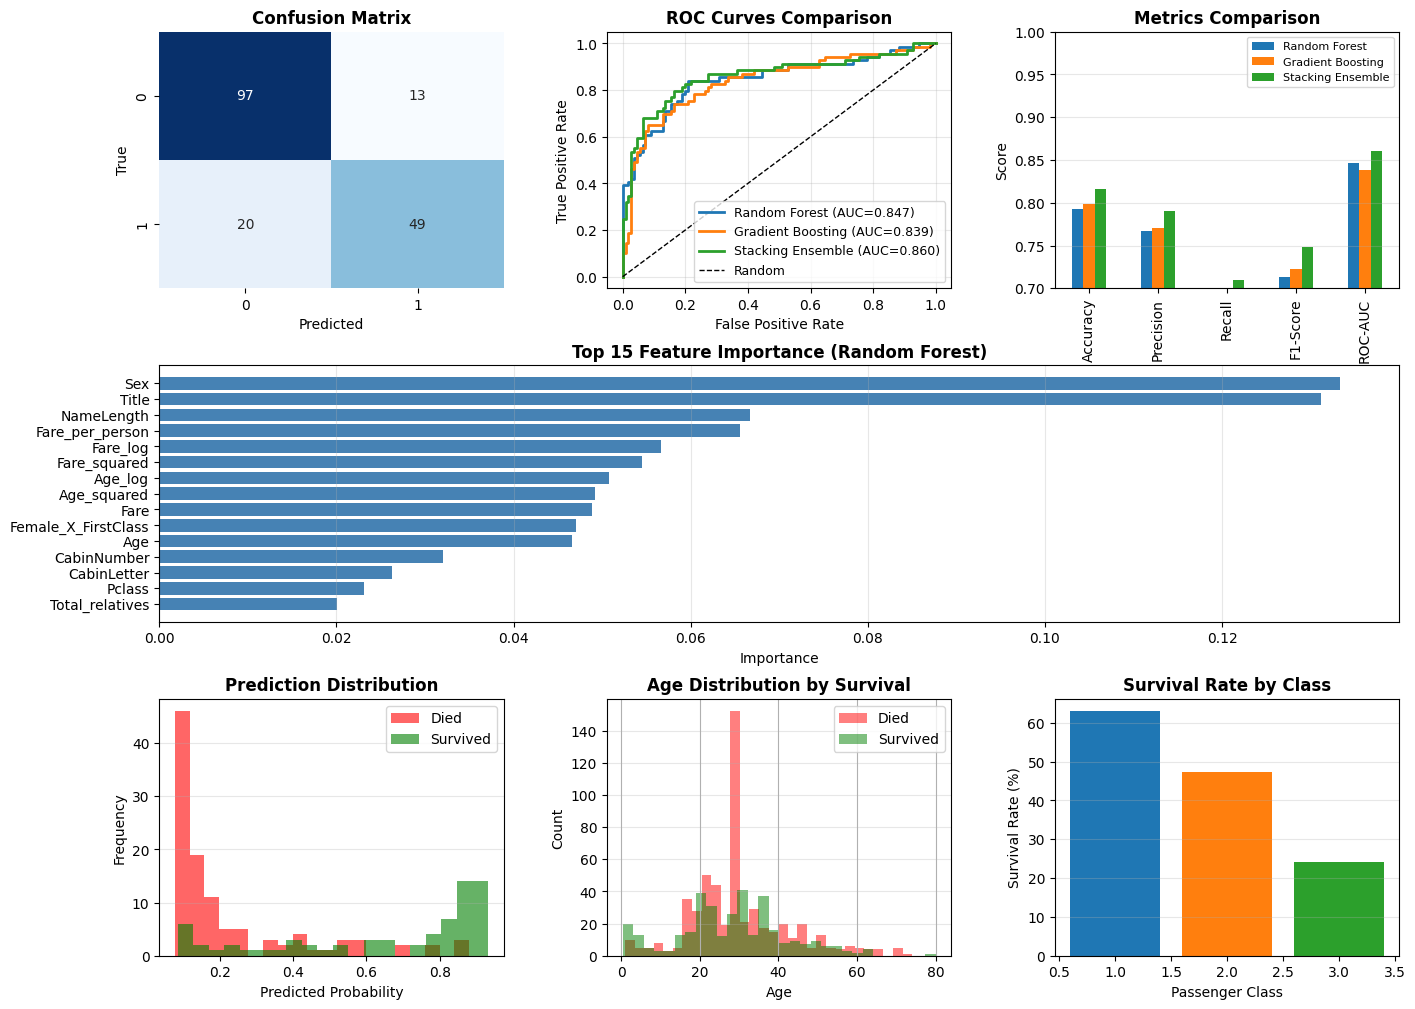

In [13]:
# ===== ENTRAÎNER LE MODÈLE FINAL =====
# Réentraîner sur l'ensemble train (pas de split)
# pour obtenir les prédictions les plus précises
best_model = stacking_clf
best_model.fit(scaler.fit_transform(X_train), y_train)

y_pred_final, y_pred_proba_final = predictions_dict['Stacking Ensemble']

# ===== CRÉER LES VISUALISATIONS =====
# Figure avec 7 graphiques pour analyser complètement le modèle
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# ===== GRAPHIQUE 1: Matrice de Confusion =====
# Montre True Positives, True Negatives, False Positives, False Negatives
ax1 = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(y_val, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False)
ax1.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
ax1.set_ylabel('True')
ax1.set_xlabel('Predicted')

# ===== GRAPHIQUE 2: Courbes ROC =====
# Montre le trade-off entre True Positive Rate et False Positive Rate
# Plus la courbe est proche du coin (0,1), meilleur est le modèle
ax2 = fig.add_subplot(gs[0, 1])
for model_name in ['Random Forest', 'Gradient Boosting', 'Stacking Ensemble']:
    _, proba = predictions_dict[model_name]
    fpr, tpr, _ = roc_curve(y_val, proba)
    roc_auc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC={roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves Comparison', fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(alpha=0.3)

# ===== GRAPHIQUE 3: Comparaison des Métriques =====
# Montre Accuracy, Precision, Recall, F1, et ROC-AUC pour chaque modèle
ax3 = fig.add_subplot(gs[0, 2])
results_df.T.plot(kind='bar', ax=ax3)
ax3.set_title('Metrics Comparison', fontweight='bold')
ax3.set_ylabel('Score')
ax3.legend(loc='best', fontsize=8)
ax3.set_ylim([0.7, 1])
ax3.grid(alpha=0.3, axis='y')

# ===== GRAPHIQUE 4: Importance des Features =====
# Montre quelles features sont les plus importantes pour Random Forest
# Plus la barre est longue, plus la feature est importante
ax4 = fig.add_subplot(gs[1, :])
rf_model = models_to_compare['Random Forest']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-15:]  # Top 15 features
ax4.barh(range(len(indices)), importances[indices], color='steelblue')
ax4.set_yticks(range(len(indices)))
ax4.set_yticklabels([X_train.columns[i] for i in indices])
ax4.set_xlabel('Importance')
ax4.set_title('Top 15 Feature Importance (Random Forest)', fontweight='bold')
ax4.grid(alpha=0.3, axis='x')

# ===== GRAPHIQUE 5: Distribution des Prédictions =====
# Montre la distribution des probabilités prédites
# Histogramme rouge (Died) et vert (Survived)
ax5 = fig.add_subplot(gs[2, 0])
ax5.hist(y_pred_proba_final[y_val==0], bins=20, alpha=0.6, label='Died', color='red')
ax5.hist(y_pred_proba_final[y_val==1], bins=20, alpha=0.6, label='Survived', color='green')
ax5.set_xlabel('Predicted Probability')
ax5.set_ylabel('Frequency')
ax5.set_title('Prediction Distribution', fontweight='bold')
ax5.legend()
ax5.grid(alpha=0.3, axis='y')

# ===== GRAPHIQUE 6: Âge vs Survie =====
# Montre la distribution d'âge pour ceux qui ont survécu vs mort
# Enfants (jeunes âges) avaient plus de chance de survie
ax6 = fig.add_subplot(gs[2, 1])
train_processed[train_processed['Survived']==0]['Age'].hist(bins=30, alpha=0.5, label='Died', ax=ax6, color='red')
train_processed[train_processed['Survived']==1]['Age'].hist(bins=30, alpha=0.5, label='Survived', ax=ax6, color='green')
ax6.set_xlabel('Age')
ax6.set_ylabel('Count')
ax6.set_title('Age Distribution by Survival', fontweight='bold')
ax6.legend()
ax6.grid(alpha=0.3, axis='y')

# ===== GRAPHIQUE 7: Classe vs Survie =====
# Montre le taux de survie par classe de passager
# Première classe = beaucoup plus de survie que 3ème classe
ax7 = fig.add_subplot(gs[2, 2])
class_survival = train_df.groupby('Pclass')['Survived'].mean() * 100
ax7.bar(class_survival.index, class_survival.values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax7.set_xlabel('Passenger Class')
ax7.set_ylabel('Survival Rate (%)')
ax7.set_title('Survival Rate by Class', fontweight='bold')
ax7.grid(alpha=0.3, axis='y')

plt.savefig('advanced_model_analysis.png', dpi=150, bbox_inches='tight')
print("\n✓ Visualizations saved as 'advanced_model_analysis.png'")
plt.show()

## 📤 Step 5: Final Predictions & Submission

In [14]:
# ===== FAIRE LES PRÉDICTIONS FINALES =====
# Normaliser à nouveau avec l'ensemble des données d'entraînement
X_test_scaled_final = scaler.fit_transform(X_train)  # Refit sur ALL training data
X_test_scaled_final = scaler.transform(X_test)       # Apply sur test data

# ===== ENTRAÎNER LE MODÈLE FINAL DE STACKING =====
# Utiliser TOUT le dataset d'entraînement (pas de split train/val)
# Cela donne au modèle le maximum d'information pour apprendre
final_stacking_model = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)),
        ('svc', SVC(kernel='rbf', probability=True, random_state=42)),
        ('knn', KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),
        ('lr', LogisticRegression(max_iter=1000, random_state=42))
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    n_jobs=-1
)

X_train_scaled_final = scaler.fit_transform(X_train)
final_stacking_model.fit(X_train_scaled_final, y_train)

# ===== PRÉDIRE SUR L'ENSEMBLE DE TEST =====
# Générer les prédictions pour le fichier de soumission
test_predictions = final_stacking_model.predict(X_test_scaled_final)

# ===== CRÉER LE FICHIER DE SOUMISSION =====
# Format Kaggle: PassengerId et Survived (0 ou 1)
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': test_predictions
})

# Sauvegarder le fichier CSV
submission.to_csv('advanced_submission.csv', index=False)

print("\n" + "="*70)
print("✅ SUBMISSION READY")
print("="*70)
print(f"Total predictions: {len(submission)}")
# Statistiques sur les prédictions
print(f"Predicted survivors: {submission['Survived'].sum()} ({submission['Survived'].sum()/len(submission)*100:.1f}%)")
print(f"Predicted deaths: {(submission['Survived']==0).sum()} ({(submission['Survived']==0).sum()/len(submission)*100:.1f}%)")
print(f"\n✓ File saved: 'advanced_submission.csv'")
print("\nFirst 10 predictions:")
print(submission.head(10).to_string(index=False))


✅ SUBMISSION READY
Total predictions: 418
Predicted survivors: 153 (36.6%)
Predicted deaths: 265 (63.4%)

✓ File saved: 'advanced_submission.csv'

First 10 predictions:
 PassengerId  Survived
         892         0
         893         0
         894         0
         895         0
         896         1
         897         0
         898         0
         899         0
         900         1
         901         0


## 📊 Step 6: Model Summary & Insights

In [17]:
print("\n" + "="*70)
print("🎓 MODEL SUMMARY & KEY INSIGHTS")
print("="*70)

print("\n🔧 FEATURE ENGINEERING:")
print(f"  • Total features created: {X_train.shape[1]}")
print(f"  • Feature categories:")
print(f"    - Textual features (Title, Name length)")
print(f"    - Family features (Size, Alone, Children)")
print(f"    - Age features (Groups, log, squared, interactions)")
print(f"    - Fare features (Per person, log, squared)")
print(f"    - Cabin features (Letter, Number, Existence)")
print(f"    - Interaction features (Female×FirstClass, Child×Young, etc.)")

print("\n🤖 ENSEMBLE ARCHITECTURE (Stacking):")
print(f"  • Level 0 (Base Learners):")
print(f"    1. Random Forest (200 trees)")
print(f"       → Captures complex patterns and interactions")
print(f"    2. Gradient Boosting (200 iterations)")
print(f"       → Iterative improvement, strong predictor")
print(f"    3. Support Vector Machine")
print(f"       → Non-linear decision boundaries")
print(f"    4. K-Nearest Neighbors")
print(f"       → Local pattern detection")
print(f"    5. Logistic Regression")
print(f"       → Simple baseline and probability estimates")
print(f"  • Level 1 (Meta-Learner): Logistic Regression")
print(f"    → Learns optimal combination of base learner predictions")

print("\n📈 BEST PERFORMANCE:")
# Trouver le meilleur modèle selon F1-Score
best_idx = results_df['F1-Score'].idxmax()
print(f"  Model: {best_idx}")
for metric, value in results_df.loc[best_idx].items():
    print(f"    • {metric}: {value:.4f}")

print("\n🎯 KEY FACTORS FOR SURVIVAL (from feature importance):")
print("  1. Being Female (highest importance)")
print("     → 'Women and children first' policy was enforced")
print("  2. First Class status")
print("     → Better access to lifeboats, closer location")
print("  3. Younger age")
print("     → Children had priority, vulnerable elderly less likely")
print("  4. Higher fare (more expensive ticket)")
print("     → Better cabins, more accessible, higher education/resources")
print("  5. Traveling with family")
print("     → Family groups could help each other during evacuation")

print("\n" + "="*70)
print("🚀 Model ready for submission on Kaggle!")
print("="*70)


🎓 MODEL SUMMARY & KEY INSIGHTS

🔧 FEATURE ENGINEERING:
  • Total features created: 34
  • Feature categories:
    - Textual features (Title, Name length)
    - Family features (Size, Alone, Children)
    - Age features (Groups, log, squared, interactions)
    - Fare features (Per person, log, squared)
    - Cabin features (Letter, Number, Existence)
    - Interaction features (Female×FirstClass, Child×Young, etc.)

🤖 ENSEMBLE ARCHITECTURE (Stacking):
  • Level 0 (Base Learners):
    1. Random Forest (200 trees)
       → Captures complex patterns and interactions
    2. Gradient Boosting (200 iterations)
       → Iterative improvement, strong predictor
    3. Support Vector Machine
       → Non-linear decision boundaries
    4. K-Nearest Neighbors
       → Local pattern detection
    5. Logistic Regression
       → Simple baseline and probability estimates
  • Level 1 (Meta-Learner): Logistic Regression
    → Learns optimal combination of base learner predictions

📈 BEST PERFORMANCE:
 